In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [3]:
data = pd.read_csv("StudentPerformanceFactors1.csv")
data.T

,0,1,2,3,4,5,6,7,8,9,...,6597,6598,6599,6600,6601,6602,6603,6604,6605,6606
Hours_Studied,23,19,24,29,19,19,29,25,17,23,...,16,9,30,12,20,25,23,20,10,15
Attendance,84,64,98,89,92,88,84,78,94,98,...,91,87,94,98,83,69,76,90,86,67
Parental_Involvement,Low,Low,Medium,Low,Medium,Medium,Medium,Low,Medium,Medium,...,High,Low,Medium,Medium,Medium,High,High,Medium,High,Medium
Access_to_Resources,High,Medium,Medium,Medium,Medium,Medium,Low,High,High,Medium,...,Medium,Medium,Low,Low,Low,Medium,Medium,Low,High,Low
Extracurricular_Activities,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,...,Yes,Yes,No,Yes,No,No,No,Yes,Yes,Yes
Sleep_Hours,7,8,7,8,6,8,7,6,6,8,...,6,6,5,4,6,7,8,6,6,9
Previous_Scores,73,59,91,98,65,89,68,50,80,71,...,72,64,52,54,51,76,81,65,91,94
Motivation_Level,Low,Low,Medium,Medium,Medium,Medium,Low,Medium,High,Medium,...,High,Medium,Low,Medium,Low,Medium,Medium,Low,High,Medium
Internet_Access,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,...,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes
Tutoring_Sessions,0,2,2,1,3,3,1,1,0,0,...,0,1,3,2,2,1,3,3,2,0


In [4]:
#find null values(missing values) of each col:
data.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [5]:
#Descriptive Statistics
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.029060,1.468120,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.493719,1.230570,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.967610,1.031231,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.190101,4.088990,24.0,65.0,67.0,69.0,100.0


In [6]:
data.duplicated().sum()

np.int64(0)

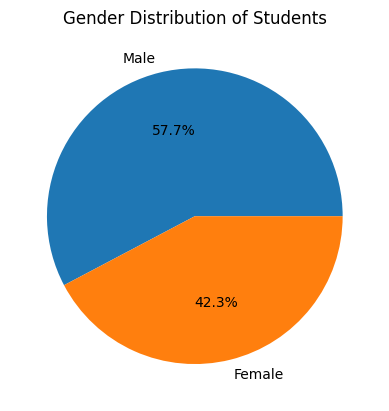

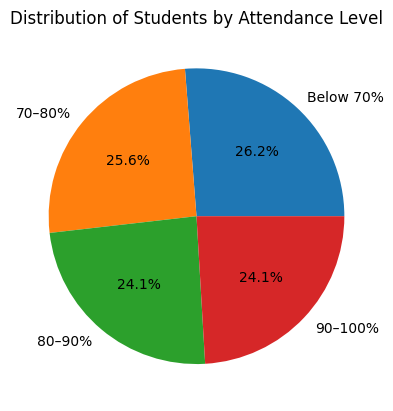

In [7]:
""" 

-----Extract Patterns----- 
1. Gender Distribution of Students
2.Distribution of Students by Attendance Level

"""

# Gender Distribution of Students
gender_count = data['Gender'].value_counts()

plt.figure()
plt.pie(gender_count, labels=gender_count.index, autopct='%1.1f%%')
plt.title("Gender Distribution of Students")
plt.show()

#Distribution of Students by Attendance Level
data['Attendance_Category'] = pd.cut(
    data['Attendance'],
    bins=[0, 70, 80, 90, 100],
    labels=['Below 70%', '70–80%', '80–90%', '90–100%']
)

attendance_count = data['Attendance_Category'].value_counts()

plt.figure()
plt.pie(attendance_count, labels=attendance_count.index, autopct='%1.1f%%')
plt.title("Distribution of Students by Attendance Level")
plt.show()

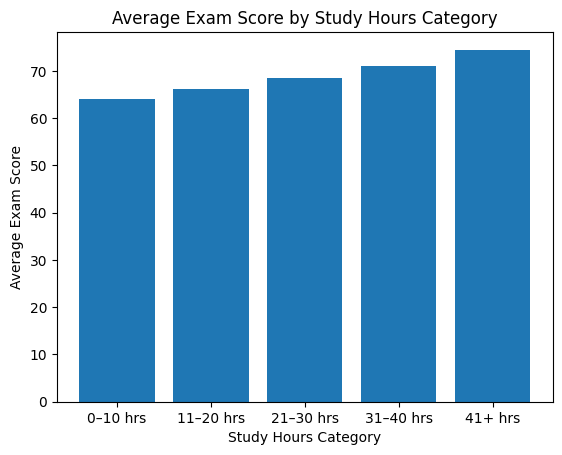

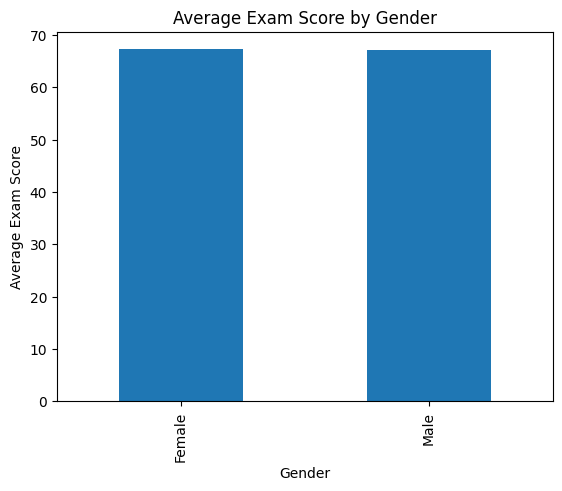

In [8]:
"""  
------insights supporting------
1.Study Effort vs Academic Performance
    Insight:
            Students who study more hours tend to score higher in exams.
            This supports encouraging effective and consistent study habits.

"""

data['Study_Hours_Category'] = pd.cut(
    data['Hours_Studied'],
    bins=[0, 10, 20, 30, 40, 50],
    labels=['0–10 hrs', '11–20 hrs', '21–30 hrs', '31–40 hrs', '41+ hrs']
)

avg_score = data.groupby('Study_Hours_Category')['Exam_Score'].mean()

plt.figure()
plt.bar(avg_score.index, avg_score.values)
plt.xlabel("Study Hours Category")
plt.ylabel("Average Exam Score")
plt.title("Average Exam Score by Study Hours Category")
plt.show()

"""
2. Gender-wise Average Exam Score

    Insight:
            Male and female students show a nearly balanced average exam score.
            This supports fair and equal academic policies for all genders.
            
"""


gender_score = data.groupby('Gender')['Exam_Score'].mean()

plt.figure()
gender_score.plot(kind='bar')
plt.title('Average Exam Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Exam Score')
plt.show()


In [9]:
low_score_students = data[data['Exam_Score'] < 40]
low_score_students.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Attendance_Category,Study_Hours_Category
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,Public,Neutral,4,No,College,Near,Female,24,90–100%,11–20 hrs
818,20,92,Medium,Low,No,5,86,Low,Yes,0,...,Public,Neutral,2,No,Postgraduate,Moderate,Female,34,90–100%,11–20 hrs
894,28,94,Medium,High,Yes,7,80,Medium,Yes,3,...,Public,Positive,4,No,Postgraduate,Far,Male,35,90–100%,21–30 hrs
1103,19,67,Medium,Medium,Yes,6,75,High,Yes,1,...,Public,Neutral,3,No,College,Near,Female,26,Below 70%,11–20 hrs
1154,30,73,Low,Medium,No,7,68,Medium,Yes,0,...,Public,Positive,2,No,Postgraduate,Near,Male,35,70–80%,21–30 hrs


In [10]:
# Create At Risk column based on decision rule
data['At_Risk'] = (
    (data['Exam_Score'] < 40) |
    (data['Attendance'] < 70) |
    (data['Hours_Studied'] < 10)
)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Attendance_Category,Study_Hours_Category,At_Risk
